# Домашнє завдання: ETL-пайплайни для аналітиків даних

Це ДЗ передбачене під виконання на локальній машині. Виконання з Google Colab буде суттєво ускладнене.

## Підготовка
1. Переконайтесь, що у вас встановлены необхідні бібліотеки:
   ```bash
   pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv
   ```

2. Створіть файл `.env` з параметрами підключення до бази даних classicmodels. Базу даних ви можете отримати через

  - docker-контейнер згідно існтрукції в [документі](https://www.notion.so/hannapylieva/Docker-1eb94835849480c9b2e7f5dc22ee4df9), також відео інструкції присутні на платформі - уроки "MySQL бази, клієнт для роботи з БД, Docker і ChatGPT для запитів" та "Як встановити Docker для роботи з базами даних без терміналу"
  - або встановивши локально цю БД - для цього перегляньте урок "Опціонально. Встановлення MySQL та  БД Сlassicmodels локально".
  
  Приклад `.env` файлу ми створювали в лекції. Ось його обовʼязкове наповнення:
    ```
    DB_HOST=your_host
    DB_PORT=3306 або 3307 - той, який Ви налаштували
    DB_USER=your_username
    DB_PASSWORD=your_password
    DB_NAME=classicmodels
    ```
  Якщо ви створили цей файл під час перегляду лекції - **новий створювати не треба**. Замініть лише назву БД, або пропишіть назву в коді створення підключення (замість отримання назви цільової БД зі змінних оточення). Але переконайтесь, що до `.env` файл лежить в тій самій папці, що і цей ноутбук.

  **УВАГА!** НЕ копіюйте скрит для **створення** `.env` файлу. В лекції він наводиться для прикладу. І давалось пояснення, що в реальних проєктах ми НІКОЛИ не пишемо доступи до бази в коді. Копіювання скрипта для створення `.env` файлу сюди в ДЗ буде вважатись грубою помилкою і ми зніматимемо бали.

3. Налаштуйте підключення через SQLAlchemy до БД за прикладом в лекції.

Рекомендую вивести (відобразити) змінну engine після створення. Вона має бути не None! Якщо None - значить у Вас не підтягнулись налаштування з .env файла.

Ви також можете налаштувати параметри підключення до БД без .env файла, просто прописавши текстом в відповідних місцях. Це - не рекомендований підхід.

In [1]:
pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
# перевірка, що .env файл існує
import os
print(os.path.exists(".env"))

True


In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
database = os.getenv("DB_NAME")

In [4]:
from sqlalchemy import create_engine

connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"

engine = create_engine(connection_string)

print("Підключення створено")

Підключення створено


### Завдання 1: Створення таблиці курсів валют та API інтеграція (2 бали)

**Повторіть процедуру з лекції:** створіть таблицю для курсів валют, але вже в цій базі даних. Результатом має бути нова таблиця з курсами валют USD, EUR, UAH в БД (можна завантажити більше валют). Продемонструйте, що таблиця була додана, використовуючи SELECT.

Тобто тут ви можете прямо скопіювати код з лекції, внести необхідні зміни і запустити. Головне - отримати таблицю в БД classicmodels.

In [5]:
from sqlalchemy import text
import pandas as pd
import requests
import datetime

In [10]:
def create_currency_table(engine):
    create_table_sql = text("""
    CREATE TABLE IF NOT EXISTS currency_rates (
        id INT AUTO_INCREMENT PRIMARY KEY,
        currency_code VARCHAR(3) NOT NULL,
        rate_to_usd DECIMAL(10, 6) NOT NULL,
        rate_date DATE NOT NULL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
        INDEX idx_currency_date (currency_code, rate_date),
        UNIQUE KEY unique_currency_date (currency_code, rate_date)
    )
    """)

    with engine.begin() as conn:
        conn.execute(create_table_sql)

    print("✅ Таблиця currency_rates створена")

def fetch_exchange_rates():
    try:
        url = "https://api.exchangerate-api.com/v4/latest/USD"
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        data = response.json()

        rates = {
            "USD": 1.0,  # базова валюта
            "EUR": data["rates"]["EUR"],
            "UAH": data["rates"]["UAH"]
        }

        return rates, datetime.date.today()

    except Exception as e:
        print(f"❌ Помилка API: {e}")
        return None, None

def save_exchange_rates(engine, rates_dict, rate_date):

    if not rates_dict:
        print("❌ Немає даних для збереження")
        return False

    insert_sql = text("""
    INSERT INTO currency_rates (currency_code, rate_to_usd, rate_date)
    VALUES (:currency, :rate, :date)
    ON DUPLICATE KEY UPDATE
        rate_to_usd = VALUES(rate_to_usd),
        updated_at = CURRENT_TIMESTAMP
    """)

    try:
        with engine.begin() as conn:
            for currency, rate in rates_dict.items():
                conn.execute(insert_sql, {
                    "currency": currency,
                    "rate": rate,
                    "date": rate_date
                })

        print(f"✅ Збережено {len(rates_dict)} курсів валют на {rate_date}")
        return True

    except Exception as e:
        print(f"❌ Помилка збереження: {e}")
        return False

In [16]:
create_currency_table(engine)

print("📡 Отримуємо курси валют...")
rates, rate_date = fetch_exchange_rates()

if rates:
    print(f"Отримані курси на {rate_date}:")
    for currency, rate in rates.items():
        print(f"1 USD = {rate:.4f} {currency}")

    save_exchange_rates(engine, rates, rate_date)

✅ Таблиця currency_rates створена
📡 Отримуємо курси валют...
Отримані курси на 2026-03-15:
1 USD = 1.0000 USD
1 USD = 0.8730 EUR
1 USD = 44.1700 UAH
✅ Збережено 3 курсів валют на 2026-03-15


In [17]:
query_check = text("""
SELECT *
FROM currency_rates
ORDER BY rate_date DESC, currency_code
""")

df_check = pd.read_sql(query_check, engine)
print(df_check)

   id currency_code  rate_to_usd   rate_date          created_at  \
0   2           EUR        0.873  2026-03-15 2026-03-15 18:30:27   
1   3           UAH       44.170  2026-03-15 2026-03-15 18:30:27   
2   1           USD        1.000  2026-03-15 2026-03-15 18:30:27   

           updated_at  
0 2026-03-15 18:36:46  
1 2026-03-15 18:36:46  
2 2026-03-15 18:36:46  


# Завдання 2: Створення простого ETL пайплайну (7 балів)

В цьому завданні ми створимо повноцінний ETL процес для аналізу продажів ClassicModels.

Завдання обʼємне і оцінюється відповідно. Ви можете пропустити обчислення якихось з метрик, якщо відчуєте, що вже немає сил робити це завдання. Бал буде виставлено виходячи з виконаного обʼєму та його правильності.

## Що саме треба зробити:

### Extract (Витягування даних):
На цьому етапі треба витягнути дані з БД в pandas.DataFrame для подальшої обробки.
Які дані нам потрібні (кожен пункт - в окремий фрейм даних):
1. **дані про виконані замовлення за 2004 рік** - з'єднати таблиці orders, orderdetails, products, customers
2. **дані про продукти** - назви, категорії, ціни
3. **дані про курси валют** - використати дані з попереднього завдання

### Transform (Обробка даних):

#### 2.1 Додати розрахункові колонки до основної таблиці:
Додайте до DataFrame з продажами такі нові колонки:

- **`profit_per_item`** - прибуток з одного товару (використайте колонки: `priceEach` - `buyPrice`)
- **`total_profit`** - загальний прибуток з товарної позиції (використайте колонки: `profit_per_item` × `quantityOrdered`)
- **`total_amount_eur`** - сума в євро (використайте колонки: `total_amount` / `eur_rate`)

#### 2.2 Створити аналітичну таблицю по країнах (ТОП-5):
Згрупуйте дані по колонці **`country`** та обчисліть для кожної країни:

**Метрики для розрахунку:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Загальний дохід** - сума колонки `total_amount`
- **Загальний прибуток** - сума колонки `total_profit`
- **Кількість проданих товарів** - сума колонки `quantityOrdered`
- **Маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100

**Результат:** Таблиця з 5 найприбутковіших країн, відсортована за загальним доходом (від більшого до меншого).

#### 2.3 Створити аналітичну таблицю по продуктових лініях:
Згрупуйте дані по колонці **`productLine`** та обчисліть ті ж метрики:

**Метрики для розрахунку:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Загальний дохід** - сума колонки `total_amount`
- **Загальний прибуток** - сума колонки `total_profit`
- **Кількість проданих товарів** - сума колонки `quantityOrdered`
- **Маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100

**Результат:** Таблиця з усіма продуктовими лініями, відсортована за загальним доходом.

#### 2.4 Створити підсумкову інформацію (Executive Summary):
Розрахуйте загальні показники бізнесу за 2004 рік:

**Фінансові показники:**
- **Загальний дохід в доларах** - сума всієї колонки `total_amount`
- **Загальний дохід в євро** - сума всієї колонки `total_amount_eur`
- **Загальний прибуток в доларах** - сума всієї колонки `total_profit`
- **Загальна маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100
- **Середній розмір замовлення** - середнє значення колонки `total_amount`

**Операційні показники:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Кількість унікальних клієнтів** - унікальні значення колонки `customerName`
- **Період даних** - мінімальна та максимальна дата з колонки `orderDate`

**Топ показники:**
- **Найприбутковіша країна** - перший рядок з таблиці країн (колонка `country`)
- **Найприбутковіша продуктова лінія** - перший рядок з таблиці продуктів (колонка `productLine`)

### Load (Збереження результатів):
В цій частині ми зберігаємо результати наших обчислень.
Використайте приклади коду з лекцій та адаптуйте його під цей ETL процес.
Що Вам потрібно створити:

#### 3.1 Excel файл з трьома вкладками:
- **"Summary"** - підсумкова інформація у вигляді таблиці "Показник - Значення"
- **"Top_Countries"** - аналітика по топ-5 країнах
- **"Product_Lines"** - аналітика по всіх продуктових лініях

#### 3.2 Візуалізація:
- Створіть стовпчикову діаграму топ-5 країн за доходом.
- Створіть pie chart з відсотковим розподілом доходу в USD по продуктових лінійках.

## РЕКОМЕНДАЦІЇ ДО ВИКОНАННЯ:

### Покрокова стратегія виконання:
1. Спочатку протестуйте Extract просто в Jupyter notebook (без фукнції) - переконайтеся що SQL запит працює і повертає дані за 2004 рік
2. Потім протестуйте кожен Transform окремо - виведіть проміжні результати
3. Нарешті протестуйте Load - перевірте що файли створюються правильно  
4. Тільки після цього обгортайте все в функцію

### Як перевірити що все працює:
- Виводьте на екран, який етап зараз відбувається
- Виведіть кількість записів після кожного кроку
- Покажіть перші 5 рядків кожної аналітичної таблиці
- Перевірте що дати належать 2004 року
- Переконайтеся що маржа прибутку в розумних межах (0-50%)

In [18]:
import matplotlib.pyplot as plt

In [53]:
def create_sales_etl_report(engine, output_dir="reports"):

    print("🚀 Запуск ETL пайплайну...")
    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    try:
        print("📥 1. EXTRACT - Витягування даних...")

        sales_query = text("""
            SELECT
                o.orderNumber,
                o.orderDate,
                o.status,
                c.customerNumber,
                c.customerName,
                c.country,
                od.productCode,
                od.quantityOrdered,
                od.priceEach,
                od.orderLineNumber,
                p.productName,
                p.productLine,
                p.buyPrice,
                (od.quantityOrdered * od.priceEach) AS total_amount
            FROM orders o
            JOIN customers c
                ON o.customerNumber = c.customerNumber
            JOIN orderdetails od
                ON o.orderNumber = od.orderNumber
            JOIN products p
                ON od.productCode = p.productCode
            WHERE YEAR(o.orderDate) = 2004
        """)

        df_sales = pd.read_sql(sales_query, engine, parse_dates=["orderDate"])

        products_query = text("""
            SELECT
                productCode,
                productName,
                productLine,
                buyPrice,
                MSRP
            FROM products
        """)

        df_products = pd.read_sql(products_query, engine)

        currency_query = text("""
            SELECT currency_code, rate_to_usd, rate_date
            FROM currency_rates
            WHERE currency_code IN ('USD', 'EUR', 'UAH')
            ORDER BY rate_date DESC
        """)

        df_currency = pd.read_sql(currency_query, engine, parse_dates=["rate_date"])

        print(f"   ✅ Продажів завантажено: {len(df_sales)} рядків")
        print(f"   ✅ Продуктів завантажено: {len(df_products)} рядків")
        print(f"   ✅ Курсів валют завантажено: {len(df_currency)} рядків")

        if df_sales.empty:
            print("❌ Немає даних продажів за 2004 рік")
            return None

        print("🔧 2. TRANSFORM - Обробка даних...")

        eur_rates = df_currency[df_currency["currency_code"] == "EUR"].copy()

        if eur_rates.empty:
            raise ValueError("У таблиці currency_rates немає курсу EUR")

        latest_eur_rate = eur_rates.iloc[0]["rate_to_usd"]

        df_sales["profit_per_item"] = df_sales["priceEach"] - df_sales["buyPrice"]
        df_sales["total_profit"] = df_sales["profit_per_item"] * df_sales["quantityOrdered"]
        df_sales["total_amount_eur"] = df_sales["total_amount"] / latest_eur_rate

        print("   ✅ Додано колонки: profit_per_item, total_profit, total_amount_eur")

        df_countries = (
            df_sales.groupby("country", as_index=False)
            .agg(
                unique_orders=("orderNumber", "nunique"),
                total_revenue=("total_amount", "sum"),
                total_profit=("total_profit", "sum"),
                total_items_sold=("quantityOrdered", "sum")
            )
        )

        df_countries["profit_margin_pct"] = (
            df_countries["total_profit"] / df_countries["total_revenue"] * 100
        )

        df_countries = df_countries.sort_values(
            "total_revenue", ascending=False
        ).head(5).reset_index(drop=True)

        df_product_lines = (
            df_sales.groupby("productLine", as_index=False)
            .agg(
                unique_orders=("orderNumber", "nunique"),
                total_revenue=("total_amount", "sum"),
                total_profit=("total_profit", "sum"),
                total_items_sold=("quantityOrdered", "sum")
            )
        )

        df_product_lines["profit_margin_pct"] = (
            df_product_lines["total_profit"] / df_product_lines["total_revenue"] * 100
        )

        df_product_lines = df_product_lines.sort_values(
            "total_revenue", ascending=False
        ).reset_index(drop=True)

        total_revenue_usd = df_sales["total_amount"].sum()
        total_revenue_eur = df_sales["total_amount_eur"].sum()
        total_profit_usd = df_sales["total_profit"].sum()
        total_margin_pct = (total_profit_usd / total_revenue_usd) * 100

        order_totals = (
            df_sales.groupby("orderNumber", as_index=False)
            .agg(order_total=("total_amount", "sum"))
        )
        average_order_size = order_totals["order_total"].mean()

        summary_df = pd.DataFrame({
            "Показник": [
                "Загальний дохід в доларах",
                "Загальний дохід в євро",
                "Загальний прибуток в доларах",
                "Загальна маржа прибутку (%)",
                "Середній розмір замовлення",
                "Кількість унікальних замовлень",
                "Кількість унікальних клієнтів",
                "Початок періоду",
                "Кінець періоду",
                "Найприбутковіша країна",
                "Найприбутковіша продуктова лінія"
            ],
            "Значення": [
                round(total_revenue_usd, 2),
                round(total_revenue_eur, 2),
                round(total_profit_usd, 2),
                round(total_margin_pct, 2),
                round(average_order_size, 2),
                df_sales["orderNumber"].nunique(),
                df_sales["customerName"].nunique(),
                df_sales["orderDate"].min().date(),
                df_sales["orderDate"].max().date(),
                df_countries.iloc[0]["country"],
                df_product_lines.iloc[0]["productLine"]
            ]
        })

        print(f"   ✅ Унікальних замовлень: {df_sales['orderNumber'].nunique()}")
        print(f"   ✅ Унікальних клієнтів: {df_sales['customerName'].nunique()}")
        print(f"   ✅ Період: {df_sales['orderDate'].min().date()} - {df_sales['orderDate'].max().date()}")

        print("💾 3. LOAD - Збереження результатів...")

        excel_path = os.path.join(output_dir, f"sales_etl_report_{timestamp}.xlsx")

        with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
            summary_df.to_excel(writer, sheet_name="Summary", index=False)
            df_countries.to_excel(writer, sheet_name="Top_Countries", index=False)
            df_product_lines.to_excel(writer, sheet_name="Product_Lines", index=False)

        print(f"   ✅ Excel файл створено: {excel_path}")

        print("📊 4. Візуалізація...")

        plt.figure(figsize=(10, 6))
        plt.bar(df_countries["country"], df_countries["total_revenue"])
        plt.title("Top-5 країн за доходом")
        plt.xlabel("Країна")
        plt.ylabel("Дохід (USD)")
        plt.xticks(rotation=45)
        plt.tight_layout()

        bar_chart_path = os.path.join(output_dir, f"top5_countries_{timestamp}.png")
        plt.savefig(bar_chart_path, bbox_inches="tight")
        plt.show()

        plt.figure(figsize=(8, 8))
        plt.pie(
            df_product_lines["total_revenue"],
            labels=df_product_lines["productLine"],
            autopct="%1.1f%%",
            startangle=90
        )
        plt.title("Розподіл доходу по продуктових лініях (USD)")
        plt.tight_layout()

        pie_chart_path = os.path.join(output_dir, f"product_lines_pie_{timestamp}.png")
        plt.savefig(pie_chart_path, bbox_inches="tight")
        plt.show()

        print("✅ ETL пайплайн завершено успішно")

        return {
            "sales": df_sales,
            "products": df_products,
            "currencies": df_currency,
            "top_countries": df_countries,
            "product_lines": df_product_lines,
            "summary": summary_df,
            "excel_path": excel_path,
            "bar_chart_path": bar_chart_path,
            "pie_chart_path": pie_chart_path
        }

    except Exception as e:
        print(f"❌ Помилка в ETL пайплайні: {e}")
        return None

🚀 Запуск ETL пайплайну...
📥 1. EXTRACT - Витягування даних...
   ✅ Продажів завантажено: 1421 рядків
   ✅ Продуктів завантажено: 110 рядків
   ✅ Курсів валют завантажено: 3 рядків
🔧 2. TRANSFORM - Обробка даних...
   ✅ Додано колонки: profit_per_item, total_profit, total_amount_eur
   ✅ Унікальних замовлень: 151
   ✅ Унікальних клієнтів: 89
   ✅ Період: 2004-01-02 - 2004-12-17
💾 3. LOAD - Збереження результатів...
   ✅ Excel файл створено: reports\sales_etl_report_20260315_205732.xlsx
📊 4. Візуалізація...


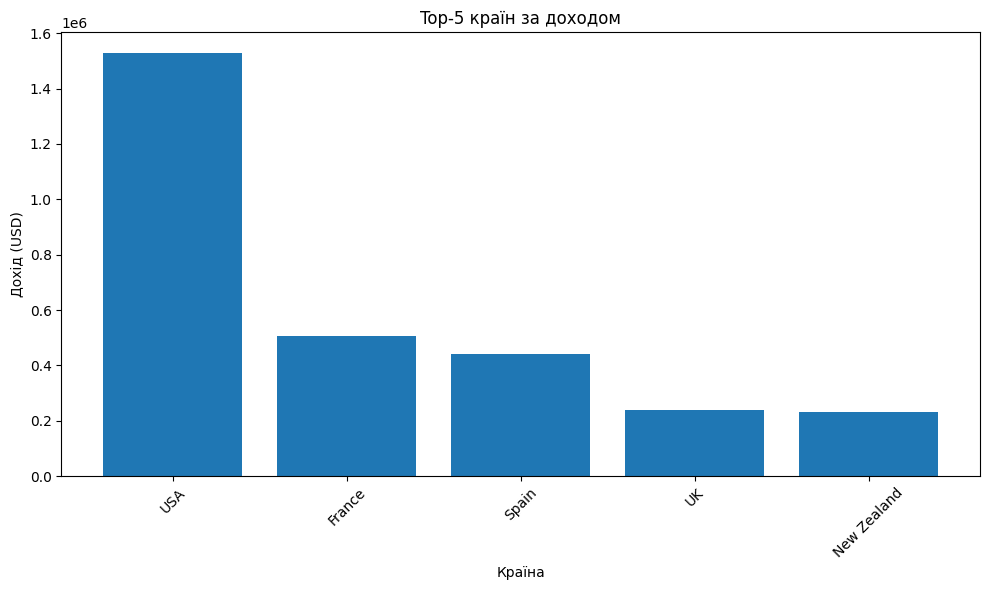

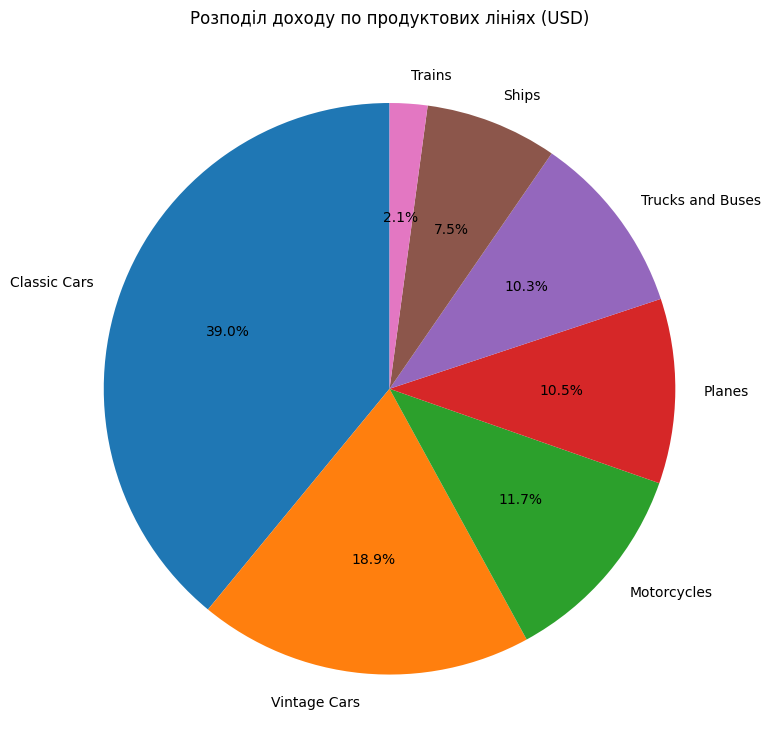

✅ ETL пайплайн завершено успішно


In [54]:
result = create_sales_etl_report(engine)

In [57]:
if result:
    print("\n=== ПЕРШІ 5 РЯДКІВ ПРОДАЖІВ ===")
    display(result["sales"].head())

    print("\n=== TOP COUNTRIES ===")
    display(result["top_countries"].head())

    print("\n=== PRODUCT LINES ===")
    display(result["product_lines"].head())

    print("\n=== SUMMARY ===")
    display(result["summary"])


=== ПЕРШІ 5 РЯДКІВ ПРОДАЖІВ ===


,orderNumber,orderDate,status,customerNumber,customerName,country,productCode,quantityOrdered,priceEach,orderLineNumber,productName,productLine,buyPrice,total_amount,profit_per_item,total_profit,total_amount_eur
0,10345,2004-11-25,Shipped,103,Atelier graphique,France,S24_2022,43,38.98,1,1938 Cadillac V-16 Presidential Limousine,Vintage Cars,20.61,1676.14,18.37,789.91,1919.977090
1,10298,2004-09-27,Shipped,103,Atelier graphique,France,S18_2625,32,60.57,2,1936 Harley Davidson El Knucklehead,Motorcycles,24.23,1938.24,36.34,1162.88,2220.206186
2,10298,2004-09-27,Shipped,103,Atelier graphique,France,S10_2016,39,105.86,1,1996 Moto Guzzi 1100i,Motorcycles,68.99,4128.54,36.87,1437.93,4729.140893
3,10346,2004-11-29,Shipped,112,Signal Gift Stores,USA,S24_3969,22,38.57,4,1936 Mercedes Benz 500k Roadster,Vintage Cars,21.75,848.54,16.82,370.04,971.981672
4,10278,2004-08-06,Shipped,112,Signal Gift Stores,USA,S24_3856,25,136.22,9,1956 Porsche 356A Coupe,Classic Cars,98.30,3405.50,37.92,948.00,3900.916380



=== TOP COUNTRIES ===


,country,unique_orders,total_revenue,total_profit,total_items_sold,profit_margin_pct
0,USA,53,1526499.65,614370.08,16719,40.246985
1,France,19,506660.01,211528.15,5632,41.749525
2,Spain,14,439881.84,175328.56,4962,39.858104
3,UK,7,238193.93,93425.03,2778,39.222255
4,New Zealand,6,233362.27,94390.14,2537,40.447901



=== PRODUCT LINES ===


,productLine,unique_orders,total_revenue,total_profit,total_items_sold,profit_margin_pct
0,Classic Cars,97,1763136.73,703837.29,16085,39.919609
1,Vintage Cars,88,854551.85,350298.70,10864,40.992094
2,Motorcycles,37,527243.84,222485.41,5976,42.197821
3,Planes,34,471971.46,182273.04,5820,38.619505
4,Trucks and Buses,40,465390.00,182082.20,5024,39.124648



=== SUMMARY ===


,Показник,Значення
0,Загальний дохід в доларах,4515905.51
1,Загальний дохід в євро,5172858.55
2,Загальний прибуток в доларах,1809381.14
3,Загальна маржа прибутку (%),40.07
4,Середній розмір замовлення,29906.66
5,Кількість унікальних замовлень,151
6,Кількість унікальних клієнтів,89
7,Початок періоду,2004-01-02
8,Кінець періоду,2004-12-17
9,Найприбутковіша країна,USA
